In [1]:
#packages
import requests
import pandas as pd
import json
from glob import glob
from pathlib import Path
import csv
import numpy as np
import matplotlib.pyplot as plt
from censusdis import data
from censusdis.datasets import ACS5

In [2]:
import re

outages_raw = pd.read_csv('/Users/JChuang/Documents/3S MP/MP/data_raw/outage_tracker.csv')

#Filter out North Carolina
outages_NC = outages_raw[outages_raw['state'] == "North Carolina"]
#Turn outage_start_estimate and outage_end_estimate to UTC datetime objects
outages_NC['outage_start_estimate'] = pd.to_datetime(outages_NC['outage_start_estimate'], utc=True).dt.tz_localize(None).dt.floor('S')
outages_NC['outage_end_estimate'] = pd.to_datetime(outages_NC['outage_end_estimate'], utc=True).dt.tz_localize(None).dt.floor('S')

#Turn fix_duration_estimate into hours
def duration_to_hours(duration_str):
    if pd.isna(duration_str):
        return None
    match = re.match(r'(?:(\d+)d )?(?:(\d+)h )?(?:(\d+)m )?(?:(\d+)s)?', duration_str)
    if not match:
        return None
    days = int(match.group(1)) if match.group(1) else 0
    hours = int(match.group(2)) if match.group(2) else 0
    minutes = int(match.group(3)) if match.group(3) else 0
    seconds = int(match.group(4)) if match.group(4) else 0
    total_hours = days * 24 + hours + minutes / 60 + seconds / 3600
    return total_hours

outages_NC['fix_duration_hours'] = outages_NC['fix_duration_estimate'].apply(duration_to_hours)

outages_NC = outages_NC.sort_values("outage_start_estimate").reset_index(drop=True)


/var/folders/x4/39bns7ns63g9446c_4gzy_tr0000gn/T/ipykernel_8937/705568491.py:8: FutureWarning: 'S' is deprecated and will be removed in a future version, please use 's' instead.
  outages_NC['outage_start_estimate'] = pd.to_datetime(outages_NC['outage_start_estimate'], utc=True).dt.tz_localize(None).dt.floor('S')
/var/folders/x4/39bns7ns63g9446c_4gzy_tr0000gn/T/ipykernel_8937/705568491.py:8: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  outages_NC['outage_start_estimate'] = pd.to_datetime(outages_NC['outage_start_estimate'], utc=True).dt.tz_localize(None).dt.floor('S')
/var/folders/x4/39bns7ns63g9446c_4gzy_tr0000gn/T/ipykernel_8937/705568491.py:9: FutureWarning: 'S' is deprecated and will be removed in a future version, please use 's' instead.
  

In [3]:
vars = [
    # Population
    "B01003_001E",
    # Income & Poverty
    "B19013_001E", "C17002_002E",
    # Housing & Vehicles
    "B25044_001E", "B25044_003E",
    # Race / Ethnicity
    "B02001_002E", "B02001_003E", "B02001_004E",
    "B02001_005E", "B02001_006E", "B02001_007E", "B02001_008E",
    # Housing Cost Burden
    "B25070_001E", "B25070_007E", "B25070_008E", "B25070_009E", "B25070_010E",
    # Education
    "B15003_022E",
    # Disability
    "B18135_001E",
    # Internet Access
    "B28002_002E",
    # Age 65+
    "B01001_020E",
    # Housing Tenure
    "B25003_003E"
]

#Pulling this data for all census tracts in NC

In [4]:
dataset = "acs/acs5"
vintage = 2022        #2024 comes out on Dec 11
state_fips = "37"     # North Carolina as string

df = data.download(
    dataset=dataset,
    vintage=vintage,
    download_variables=vars,
    # Geographic filters (must be strings)
    state=state_fips,
    county="*",        # all counties
    tract="*"          # all tracts within each county
)

#derived indicators

#Getting percentages
def pct(num, den):
    return (num/den).replace([pd.NA, float("inf")], pd.NA)

df["pct_below_50pct_poverty"] = pct(df["C17002_002E"], df["B01003_001E"])
df["pct_no_vehicle"] = pct(df["B25044_003E"], df["B25044_001E"])
df["pct_renters_cost_burdened"] = pct(
    df["B25070_007E"] + df["B25070_008E"] + df["B25070_009E"] + df["B25070_010E"],
    df["B25070_001E"]
)
df["pct_over65"] = pct(df["B01001_020E"], df["B01003_001E"])
df["pct_with_disability"] = pct(df["B18135_001E"], df["B01003_001E"])
#df["pct_no_internet"] = pct(df["B28002_002E"], df["B28002_001E"])
df["pct_nonwhite"] = 1 - pct(df["B02001_002E"], df[
    ["B02001_002E","B02001_003E","B02001_004E","B02001_005E",
     "B02001_006E","B02001_007E","B02001_008E"]
].sum(axis=1))
#df["pct_renters"] = pct(df["B25003_003E"], df["B25003_001E"])

#save dataframe
df.to_csv("./data_processed/nc_census_tracts_acs5.csv", index=False)

'''
#downloading tract boundaries for mapping
df_geo = data.download(dataset=dataset, vintage=year,
                       variables=vars, geography="tract",
                       state=state, with_geometry=True)
df_geo.to_file("nc_census_tracts_acs5.geojson", driver="GeoJSON")
'''

'\n#downloading tract boundaries for mapping\ndf_geo = data.download(dataset=dataset, vintage=year,\n                       variables=vars, geography="tract",\n                       state=state, with_geometry=True)\ndf_geo.to_file("nc_census_tracts_acs5.geojson", driver="GeoJSON")\n'

In [5]:
outages_NC['block_fips'] = outages_NC['block_fips'].astype(str)

#Take out tract and county from block FIPS
outages_NC['TRACT'] = outages_NC['block_fips'].str[5:11]

merged = outages_NC.merge(df, left_on = "TRACT", right_on = "TRACT", how = "left")


In [6]:
merged.columns

Index(['outage_identifer', 'device_lat', 'device_lon', 'block_fips',
       'convex_hull', 'jurisdiction', 'origin', 'state', 'county', 'affected',
       'cause', 'outage_start_estimate', 'outage_end_estimate',
       'fix_duration_estimate', 'outage_restored', 'fix_duration_hours',
       'TRACT', 'STATE', 'COUNTY', 'B01003_001E', 'B19013_001E', 'C17002_002E',
       'B25044_001E', 'B25044_003E', 'B02001_002E', 'B02001_003E',
       'B02001_004E', 'B02001_005E', 'B02001_006E', 'B02001_007E',
       'B02001_008E', 'B25070_001E', 'B25070_007E', 'B25070_008E',
       'B25070_009E', 'B25070_010E', 'B15003_022E', 'B18135_001E',
       'B28002_002E', 'B01001_020E', 'B25003_003E', 'pct_below_50pct_poverty',
       'pct_no_vehicle', 'pct_renters_cost_burdened', 'pct_over65',
       'pct_with_disability', 'pct_nonwhite'],
      dtype='object')

# Analysis on outages + socioeconomic data

Trying to understand whether socioeconomic conditions explain variation in outage frequency or duration.

In [7]:
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix

In [8]:
#aggregating outages to tract level in order to use TRACT as a geographic unit in modeling

tract_df = merged.groupby("TRACT").agg(
    outage_count = ("outage_identifer", "count"),
    mean_duration = ("fix_duration_hours", "mean"),
    total_affected = ("affected", "sum"),
    **{col: (col, "first") for col in df.columns if col.startswith("pct_") or col.startswith("B")}
).reset_index()

## PCA

In [17]:
features = [
    "pct_below_50pct_poverty", "pct_no_vehicle", "pct_renters_cost_burdened",
    "pct_over65", "pct_with_disability", "pct_nonwhite", "B19013_001E",
    "B15003_022E", "B18135_001E", "B28002_002E", "B01001_020E", "B25003_003E",
    "outage_count", "mean_duration", "total_affected"
]

X = tract_df[features].fillna(0)

# scale features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# PCA
pca = PCA(n_components=3)
pcs = pca.fit_transform(X_scaled)

tract_df[["PC1", "PC2", "PC3"]] = pcs

print("Explained variance ratio:", pca.explained_variance_ratio_)
pd.DataFrame(pca.components_.T, index=features, columns=["PC1","PC2","PC3"])

Explained variance ratio: [0.22249899 0.15723182 0.13391596]


,PC1,PC2,PC3
pct_below_50pct_poverty,-0.193154,0.336894,0.186229
pct_no_vehicle,-0.164564,-0.043015,0.081287
pct_renters_cost_burdened,-0.025197,0.243639,0.098156
pct_over65,-0.023979,-0.341064,0.216482
pct_with_disability,0.127255,-0.045284,0.010744
pct_nonwhite,-0.028325,0.464148,0.046098
B19013_001E,0.302670,-0.320973,-0.242372
B15003_022E,0.493225,-0.054670,0.019153
B18135_001E,0.463793,0.111524,0.201219
B28002_002E,0.495393,0.113064,0.189088


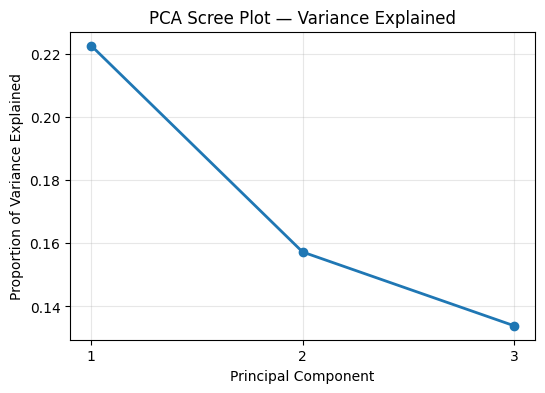

In [18]:
plt.figure(figsize=(6,4))
num_components = len(pca.explained_variance_ratio_)
x = np.arange(1, num_components+1)
plt.plot(x, pca.explained_variance_ratio_, 'o-', linewidth=2)
plt.title('PCA Scree Plot — Variance Explained')
plt.xlabel('Principal Component')
plt.ylabel('Proportion of Variance Explained')
plt.xticks(x)
plt.grid(True, alpha=0.3)
plt.show()

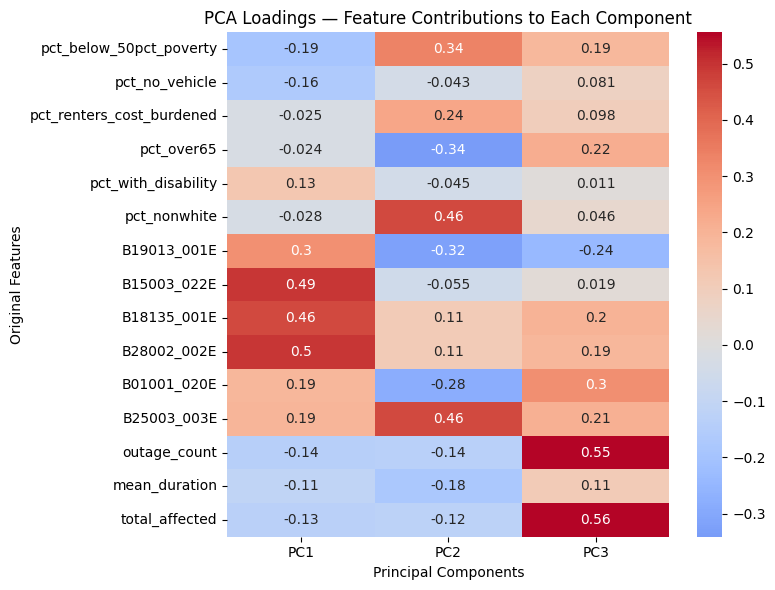

In [19]:
loadings = pd.DataFrame(
    pca.components_.T,
    index=features,  # your original feature names
    columns=[f"PC{i+1}" for i in range(pca.n_components_)]
)

plt.figure(figsize=(8,6))
sns.heatmap(loadings, annot=True, cmap="coolwarm", center=0)
plt.title("PCA Loadings — Feature Contributions to Each Component")
plt.xlabel("Principal Components")
plt.ylabel("Original Features")
plt.tight_layout()
plt.show()

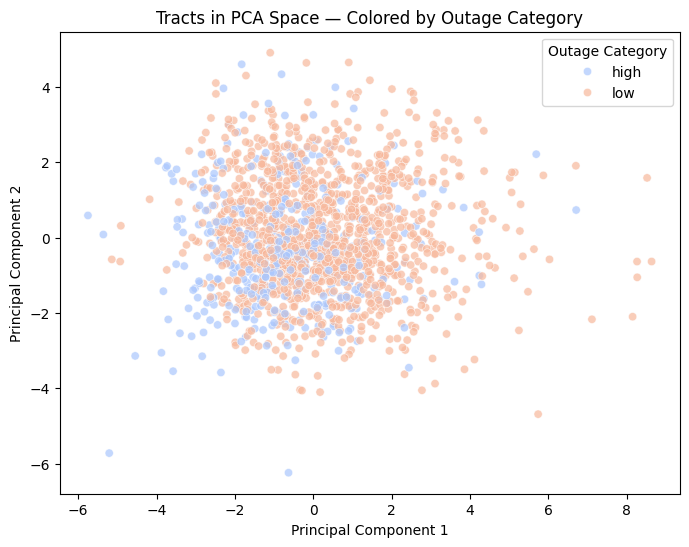

In [21]:
plt.figure(figsize=(8,6))
sns.scatterplot(
    data=tract_df, x="PC1", y="PC2",
    hue="high_outage_area",  # or duration_class, outage_count, etc.
    palette="coolwarm", alpha=0.7
)
plt.title("Tracts in PCA Space — Colored by Outage Category")
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.legend(title="Outage Category")
plt.show()

## LDA

366.75
              precision    recall  f1-score   support

        high       0.79      0.31      0.44       123
         low       0.81      0.97      0.88       369

    accuracy                           0.81       492
   macro avg       0.80      0.64      0.66       492
weighted avg       0.80      0.81      0.77       492



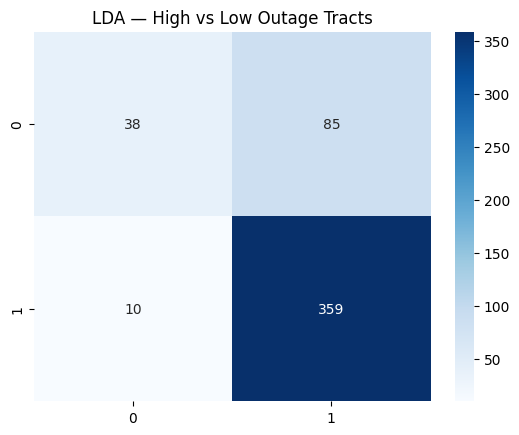

In [10]:
#gives 25% long and 75% short outages
q75 = tract_df['outage_count'].quantile(0.75)
print(q75)

tract_df['high_outage_area'] = np.where(tract_df["outage_count"]>q75, "high", "low")

X = tract_df[["PC1", "PC2", "PC3"]]
y = tract_df["high_outage_area"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y
)

lda = LinearDiscriminantAnalysis()
lda.fit(X_train, y_train)
y_pred = lda.predict(X_test)

print(classification_report(y_test, y_pred))
sns.heatmap(confusion_matrix(y_test, y_pred), annot=True, fmt="d", cmap="Blues")
plt.title("LDA — High vs Low Outage Tracts")
plt.show()

LDA seems to be good at identifying tracts with many outages, but less good at identifying low-outage tracts (row 0 --> more errors)

I think 

/var/folders/x4/39bns7ns63g9446c_4gzy_tr0000gn/T/ipykernel_8937/3092235213.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


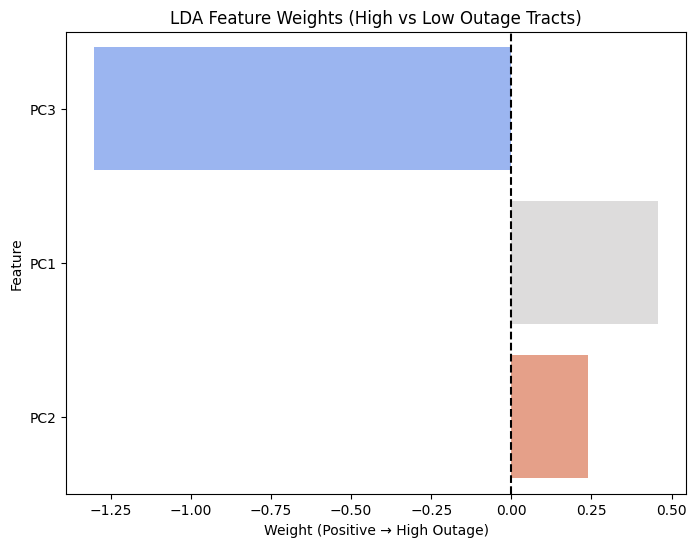

In [12]:
coef_df = pd.DataFrame(lda.coef_.T, index=X.columns, columns=['LDA Weight'])
coef_df['abs_weight'] = coef_df['LDA Weight'].abs()
coef_df.sort_values('abs_weight', ascending=False)

plt.figure(figsize=(8,6))
sns.barplot(
    y=coef_df.sort_values("abs_weight", ascending=False).index,
    x=coef_df.sort_values("abs_weight", ascending=False)["LDA Weight"],
    palette="coolwarm"
)
plt.axvline(0, color='k', linestyle='--')
plt.title("LDA Feature Weights (High vs Low Outage Tracts)")
plt.xlabel("Weight (Positive → High Outage)")
plt.ylabel("Feature")
plt.show()

In [13]:
# Loadings from PCA (how each feature contributes to each PC)
loadings = pd.DataFrame(pca.components_.T, index=features, columns=["PC1","PC2","PC3"])

# Combine with LDA coefficients
lda_loadings = pd.Series(lda.coef_[0], index=["PC1","PC2","PC3"])
contrib = loadings.dot(lda_loadings)  # total contribution of each original variable

contrib = contrib.sort_values(key=abs, ascending=False)
print(contrib)

outage_count                -0.816538
total_affected              -0.811400
B19013_001E                  0.376950
B01001_020E                 -0.376900
pct_over65                  -0.373921
pct_below_50pct_poverty     -0.250027
mean_duration               -0.241078
pct_no_vehicle              -0.191281
B15003_022E                  0.187784
pct_renters_cost_burdened   -0.080931
B25003_003E                 -0.075120
pct_nonwhite                 0.038007
pct_with_disability          0.033456
B18135_001E                 -0.022684
B28002_002E                  0.007920
dtype: float64
